- **전환율 completed / received + duration + 타임 순서**

⇒ completed / received + duration(지륜) 
⇒ 타임 순서를 붙여서 최종적으로 reward, difficulty, channel(준익)**

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform
import matplotlib.pyplot as plt

# 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [4]:
# 컬럼 정보 간단 표현
def check_basic_info(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 컬럼 정보 / 결측치 확인 정보 요약")
    print(f"{'='*80}\n")


    # 제외할 컬럼 반영
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # dict, list, set 같은 해시 불가능 값이 들어있는 컬럼은 문자열로 변환
    for col in df_copied.columns:
        try:
            df_copied[col].nunique(dropna=True)
        except TypeError:
            df_copied[col] = df_copied[col].astype(str)
    
    # 1. 전체 요약
    overview_df = pd.DataFrame({
        '항목': ['행 개수', '열 개수', '중복 행 개수'],
        '값': [df_copied.shape[0], df_copied.shape[1], df_copied.duplicated().sum()]
    })
    
    # 2. 컬럼별 요약
    summary_df = pd.DataFrame({
        '데이터타입': df_copied.dtypes.astype(str),
        '행 개수': df_copied.count(),
        '행 비율(%)': (df_copied.count() / len(df) * 100).round(2),
        '결측치 개수': df_copied.isnull().sum(),
        '결측치 비율(%)': (df_copied.isnull().sum() / len(df) * 100).round(2),
        '고유값 개수': df_copied.nunique(dropna=True)
    })
    
    # 3. 보기 좋게 정렬
    summary_df = summary_df.sort_values(
        by=['결측치 개수', '고유값 개수'],
        ascending=[False, False]
    )
    
    print("[전체 요약]")
    display(overview_df)
    
    print("[컬럼별 요약]")
    display(summary_df)

    print("[테이블 요약]")
    display(df.head())

In [5]:
# ============================================================
# 1. 원본 데이터 로드
# ============================================================
df = pd.read_csv("clean_data/starbucks_merge.csv")

# 테이블 복제
# informational은 completed 개념이 없으니 제거하고 시작
# 필요시 그냥 df2 = df.copy() 사용
df2 = df[df['offer_type'] != 'informational'].copy()
# df2 = df.copy()
check_basic_info(df2, 'transcript_portfolio')


transcript_portfolio의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,280071
1,열 개수,20
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
event_reward,float64,33182,11.85,246889,88.15,4
amount,float64,138953,49.61,141118,50.39,5103
offer_id,str,141118,50.39,138953,49.61,8
offer_reward,float64,141118,50.39,138953,49.61,4
difficulty,float64,141118,50.39,138953,49.61,4
channels,str,141118,50.39,138953,49.61,4
duration,float64,141118,50.39,138953,49.61,3
offer_type,str,141118,50.39,138953,49.61,2
web,float64,141118,50.39,138953,49.61,2
mobile,float64,141118,50.39,138953,49.61,2


[테이블 요약]


,customer_id,event,time,offer_id,amount,event_reward,offer_type,offer_reward,difficulty,duration,channels,web,email,mobile,social,gender,age,income,became_member_on,profile_missing
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,bogo,5.0,5.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,F,75.0,100000.0,2017-05-09,1
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,discount,5.0,20.0,10.0,"['web', 'email']",1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,0
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,discount,2.0,10.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,M,68.0,70000.0,2018-04-26,1
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,discount,2.0,10.0,10.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,bogo,10.0,10.0,5.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0


In [6]:
# received 분리
received = (
    df2[df2['event'] == 'offer received'][
        [
            'customer_id', 'offer_id', 'time',
            'offer_type', 'offer_reward', 'difficulty', 'duration',
            'web', 'email', 'mobile', 'social'
        ]
    ]
    .copy()
    .rename(columns={'time': 'time_received'})
)

# completed 분리
completed = (
    df2[df2['event'] == 'offer completed'][
        ['customer_id', 'offer_id', 'time']
    ]
    .copy()
    .rename(columns={'time': 'time_completed'})
)

print("received 행 수:", len(received))
print("completed 행 수:", len(completed))

received 행 수: 61042
completed 행 수: 33182


In [7]:
# ============================================================
# completed를 가장 최근의 유효한 received에 연결
# ============================================================
received = received.sort_values(
    ["customer_id", "offer_id", "time_received"]
).reset_index(drop=True)

completed = completed.sort_values(
    ["customer_id", "offer_id", "time_completed"]
).reset_index(drop=True)

# received 행 번호 만들기
received["received_idx"] = received.index

In [8]:
match_rows = []

# customer_id + offer_id 기준으로 completed를 하나씩 확인
for (customer_id, offer_id), completed_group in completed.groupby(["customer_id", "offer_id"]):
    
    # 같은 customer_id, offer_id의 received만 따로 가져오기
    received_group = received[
        (received["customer_id"] == customer_id) &
        (received["offer_id"] == offer_id)
    ].copy()
    
    # 이미 매칭된 received는 다시 쓰지 않기 위한 집합
    used_received = set()
    
    # completed 시간만 하나씩 확인
    for completed_time in completed_group["time_completed"]:
        
        # 조건에 맞는 received 후보 찾기
        candidates = received_group[
            (received_group["time_received"] <= completed_time) &
            ((completed_time - received_group["time_received"]) <= received_group["duration"] * 24) &
            (~received_group["received_idx"].isin(used_received))
        ].copy()
        
        # 후보가 없으면 다음 completed로
        if len(candidates) == 0:
            continue
        
        # 후보 중 가장 최근 received 선택
        best_received = candidates.sort_values("time_received", ascending=False).iloc[0]
        
        # 매칭 결과 저장
        match_rows.append({
            "received_idx": best_received["received_idx"],
            "time_completed": completed_time
        })
        
        # 사용한 received는 다시 못 쓰게 저장
        used_received.add(best_received["received_idx"])

# 매칭 결과 테이블
match_df = pd.DataFrame(match_rows)

In [9]:
rc = received.merge(
    match_df,
    on="received_idx",
    how='left'
)

rc["has_completed"] = rc["time_completed"].notna().astype(int)
rc["time_diff"] = rc["time_completed"] - rc["time_received"]

rc["valid_time_order"] = (
    (rc["time_diff"] >= 0)
).fillna(False).astype(int)

rc["valid_duration"] = (
    (rc["time_diff"] >= 0) &
    (rc["time_diff"] <= rc["duration"] * 24)
).fillna(False).astype(int)

rc["converted_final"] = (
    (rc["has_completed"] == 1) &
    (rc["valid_time_order"] == 1) &
    (rc["valid_duration"] == 1)
).astype(int)

rc = rc[
    [
        # 1. 고객 / 오퍼 식별
        'customer_id', 'offer_id',

        # 2. 오퍼 속성
        'offer_type', 'offer_reward', 'difficulty', 'duration',

        # 3. 채널 정보
        'web', 'email', 'mobile', 'social',

        # 4. 시간 정보
        'time_received', 'time_completed', 'time_diff',

        # 5. 판정 결과
        'has_completed', 'valid_time_order', 'valid_duration', 'converted_final'
    ]
].copy()

check_basic_info(rc, 'received + completed ')


received + completed 의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,61042
1,열 개수,17
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
time_completed,float64,33152,54.31,27890,45.69,120
time_diff,float64,33152,54.31,27890,45.69,41
customer_id,str,61042,100.00,0,0.00,16928
offer_id,str,61042,100.00,0,0.00,8
time_received,int64,61042,100.00,0,0.00,6
offer_reward,float64,61042,100.00,0,0.00,4
difficulty,float64,61042,100.00,0,0.00,4
duration,float64,61042,100.00,0,0.00,3
offer_type,str,61042,100.00,0,0.00,2
web,float64,61042,100.00,0,0.00,2


[테이블 요약]


,customer_id,offer_id,offer_type,offer_reward,difficulty,duration,web,email,mobile,social,time_received,time_completed,time_diff,has_completed,valid_time_order,valid_duration,converted_final
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,2.0,10.0,7.0,1.0,1.0,1.0,0.0,576,576.0,0.0,1,1,1,1
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,408,414.0,6.0,1,1,1,1
2,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,1.0,1.0,1.0,1.0,504,528.0,24.0,1,1,1,1
3,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,168,NaN,NaN,0,0,0,0
4,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,576,NaN,NaN,0,0,0,0


In [10]:
print("=" * 80)
print("기본 검증단계")
print("=" * 80)

print("received 기준 전체 건수:", len(rc))
print("completed가 붙은 건수:", rc['has_completed'].sum())
print("타임 순서가 맞는 건수:", rc['valid_time_order'].sum())
print("duration 안에 완료된 건수:", rc['valid_duration'].sum())
print("최종 전환 건수:", rc['converted_final'].sum())
print()
print("최종 전환율:", round(rc['converted_final'].mean() * 100, 2), "%")

기본 검증단계
received 기준 전체 건수: 61042
completed가 붙은 건수: 33152
타임 순서가 맞는 건수: 33152
duration 안에 완료된 건수: 33152
최종 전환 건수: 33152

최종 전환율: 54.31 %


[최종 전환율로 오퍼 분석]

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def add_value_labels(bars, is_percent=True, fontsize=10):
    for bar in bars:
        y = bar.get_height()
        label = f"{y*100:.1f}%" if is_percent else f"{y:.2f}"
        plt.text(
            bar.get_x() + bar.get_width()/2,
            y + 0.01,
            label,
            ha='center',
            va='bottom',
            fontsize=fontsize
        )

def apply_common_style(title, xlabel, ylabel="Conversion Rate", ylim_max=None):
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(axis='y', linestyle='--', alpha=0.5)   # 점선 추가
    if ylim_max is not None:
        plt.ylim(0, ylim_max)
    plt.tight_layout()

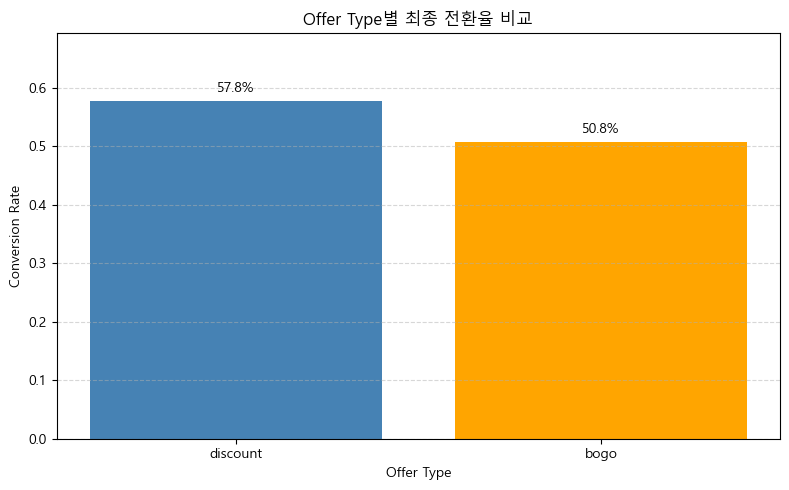

In [17]:
type_conv = (
    rc.groupby("offer_type")["converted_final"]
    .mean()
    .reset_index()
    .sort_values("converted_final", ascending=False)
)

plt.figure(figsize=(8, 5))

# 막대 2개 중 하나 주황색
colors = ['steelblue', 'orange'] if len(type_conv) == 2 else ['steelblue'] * len(type_conv)

bars = plt.bar(type_conv["offer_type"], type_conv["converted_final"], color=colors)

add_value_labels(bars, is_percent=True)
apply_common_style(
    title="Offer Type별 최종 전환율 비교",
    xlabel="Offer Type",
    ylim_max=type_conv["converted_final"].max() * 1.2
)

plt.show()

[Offer type 분석 결과]
- discount가 bogo보다 약 7%p 높음
이유 추정
1. discount => 바로 혜택 체감 (즉시 할인)
2. bogo => 추가 구매 필요 (조건 있음)

**고객은 "추가 행동이 필요한 혜택"보다 "즉시 혜택"에 더 잘 반응**

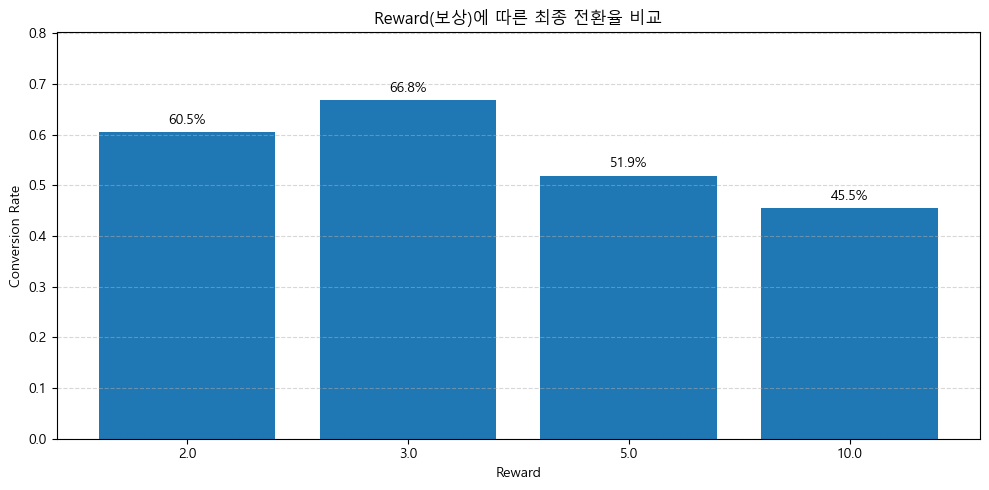

In [18]:
reward_conv = (
    rc.groupby("offer_reward")["converted_final"]
    .mean()
    .reset_index()
    .sort_values("offer_reward")
)

plt.figure(figsize=(10, 5))
bars = plt.bar(reward_conv["offer_reward"].astype(str), reward_conv["converted_final"])

add_value_labels(bars, is_percent=True)
apply_common_style(
    title="Reward(보상)에 따른 최종 전환율 비교",
    xlabel="Reward",
    ylim_max=reward_conv["converted_final"].max() * 1.2
)

plt.show()

[Reward 분석 결과]
- rewardr가 크다고 전환율이 올라가진 않는다
- reward 10이 낮은 이유: 조건(difficulty) 높을 가능성, 고객 부담 증가
- reward = 0 → informational offer
**고객은 “큰 보상”보다 “받기 쉬운 보상”에 더 반응한다**

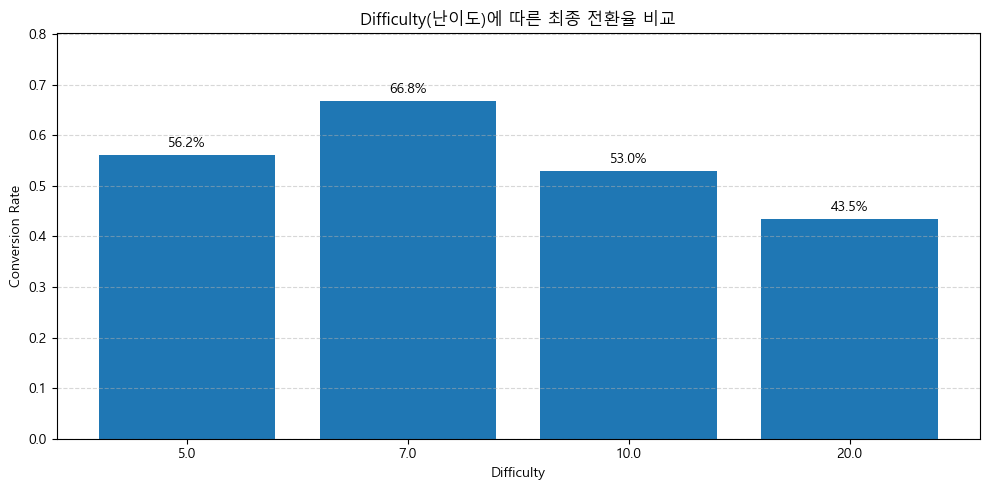

In [19]:
difficulty_conv = (
    rc.groupby("difficulty")["converted_final"]
    .mean()
    .reset_index()
    .sort_values("difficulty")
)

plt.figure(figsize=(10, 5))
bars = plt.bar(difficulty_conv["difficulty"].astype(str), difficulty_conv["converted_final"])

add_value_labels(bars, is_percent=True)
apply_common_style(
    title="Difficulty(난이도)에 따른 최종 전환율 비교",
    xlabel="Difficulty",
    ylim_max=difficulty_conv["converted_final"].max() * 1.2
)

plt.show()

[difficulty 분석 결과]
- 고객이 달성해야 하는 difficulty가 일정 수준을 넘으면 전환율이 급격히 떨어진다
- difficulty = 0 → informational offer
**고객은 일정 수준까지는 감당하지만, 그 이상은 바로 포기한다**

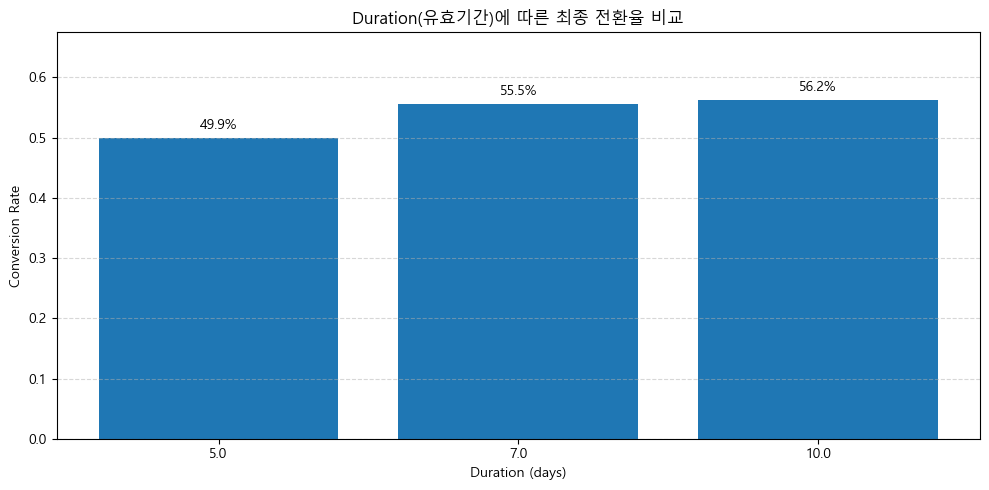

In [22]:
duration_unique = sorted(rc["duration"].dropna().unique())

if len(duration_unique) <= 4:
    duration_conv = (
        rc.groupby("duration")["converted_final"]
        .mean()
        .reset_index()
        .sort_values("duration")
    )

    plt.figure(figsize=(10, 5))
    bars = plt.bar(duration_conv["duration"].astype(str), duration_conv["converted_final"])

    add_value_labels(bars, is_percent=True)
    apply_common_style(
        title="Duration(유효기간)에 따른 최종 전환율 비교",
        xlabel="Duration (days)",
        ylim_max=duration_conv["converted_final"].max() * 1.2
    )

    plt.show()

[duration 분석 결과]
- 기간이 길수록 전환율 증가
- 7일 이후는 효율 감소
**너무 짧으면 기회 부족 // 너무 길면 긴장감 감소 및 비용 증가**

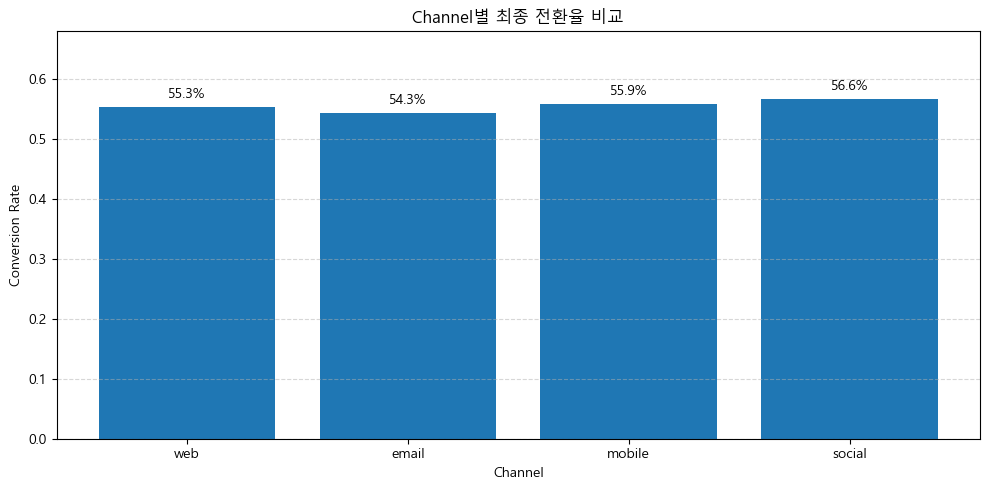

In [23]:
channel_cols = ["web", "email", "mobile", "social"]

channel_conv = []
for col in channel_cols:
    rate = rc.loc[rc[col] == 1, "converted_final"].mean()
    channel_conv.append([col, rate])

channel_conv = pd.DataFrame(channel_conv, columns=["channel", "conversion_rate"])

plt.figure(figsize=(10, 5))
bars = plt.bar(channel_conv["channel"], channel_conv["conversion_rate"])

add_value_labels(bars, is_percent=True)
apply_common_style(
    title="Channel별 최종 전환율 비교",
    xlabel="Channel",
    ylim_max=channel_conv["conversion_rate"].max() * 1.2
)

plt.show()

[channel 분석 결과]
- 채널 간 차이는 크지 않음
- social / mobile이 약간 우위
- email이 가장 낮음
**즉각 반응 채널이 강함 mobile / social → 푸시형+즉시 노출 // email → 지연+무시 가능**

[고객당 평균 거래 수]

In [24]:
# transaction 데이터 추출
transaction = df[df["event"] == "transaction"].copy()

# 고객별 거래 수
tx_per_user = transaction.groupby("customer_id").size()

# 평균
avg_tx_per_user = tx_per_user.mean()

print("고객당 평균 거래 수:", round(avg_tx_per_user, 2))

고객당 평균 거래 수: 8.38


[평균 프로모션 반응 수]

In [25]:
completed = df[df["event"] == "offer completed"]

resp_per_user = completed.groupby("customer_id").size()

avg_resp_per_user = resp_per_user.mean()

print("고객당 평균 프로모션 반응 수:", round(avg_resp_per_user, 2))

고객당 평균 프로모션 반응 수: 2.6


In [26]:
# 고객별 전환율
user_conv = rc.groupby("customer_id")["converted_final"].mean()

# 고객별 거래 수
user_tx = transaction.groupby("customer_id").size()

# 합치기
user_df = pd.concat([user_conv, user_tx], axis=1)
user_df.columns = ["conversion_rate", "transaction_count"]

# 상관관계
print(user_df.corr())

                   conversion_rate  transaction_count
conversion_rate           1.000000           0.349441
transaction_count         0.349441           1.000000


결국 오퍼 반응이 높다고 그게 실제 거래로 이뤄지는가는 약한 상관관계를 보여준다는 건데...
사실 자연스러운 결과이다. 왜냐하면 transaction이 오퍼만 보는게 아니라 전체 거래 수를 따지는거니까!
그렇다면 **오퍼를 받은 고객에 한해서 transaction**을 구하고 다시 상관계수를 확인해야 정확히 알 수 있다.

In [27]:
# transaction 데이터
transaction = df[df["event"] == "transaction"][
    ["customer_id", "time"]
].copy()

transaction = transaction.sort_values(["customer_id", "time"])

In [28]:
# transaction 존재 여부 컬럼 추가
rc["has_transaction"] = 0

# customer별로 처리 (속도 개선)
for customer_id, group in rc.groupby("customer_id"):

    tx_times = transaction[transaction["customer_id"] == customer_id]["time"].values
    
    if len(tx_times) == 0:
        continue

    for idx in group.index:
        r_time = rc.loc[idx, "time_received"]
        duration = rc.loc[idx, "duration"] * 24

        # 조건 만족하는 transaction 있는지
        has_tx = np.any(
            (tx_times >= r_time) &
            (tx_times <= r_time + duration)
        )

        if has_tx:
            rc.loc[idx, "has_transaction"] = 1

In [29]:
# 고객별 전환율
user_conv = rc.groupby("customer_id")["converted_final"].mean()

# 고객별 오퍼 기반 거래율
user_tx = rc.groupby("customer_id")["has_transaction"].mean()

user_df = pd.concat([user_conv, user_tx], axis=1)
user_df.columns = ["conversion_rate", "offer_tx_rate"]

print(user_df.corr())

                 conversion_rate  offer_tx_rate
conversion_rate         1.000000       0.491494
offer_tx_rate           0.491494       1.000000


[오퍼 전환율과 오퍼 기반 거래 간 상관계수]
- 0.49로 전환율이 실제 구매 행동과 유의미하게 연결되어 있음을 보여주지만 완전한 설명 변수는 아니므로 추가적인 고객 특성 기반 분석 필요

conversion_rate 중앙값: 0.600
offer_tx_count 중앙값: 3.000

[세그먼트별 고객 수]


,segment,customer_count
0,핵심 고객,6709
1,거래형 고객,4197
2,비활성 고객,4177
3,반응형 고객,1845


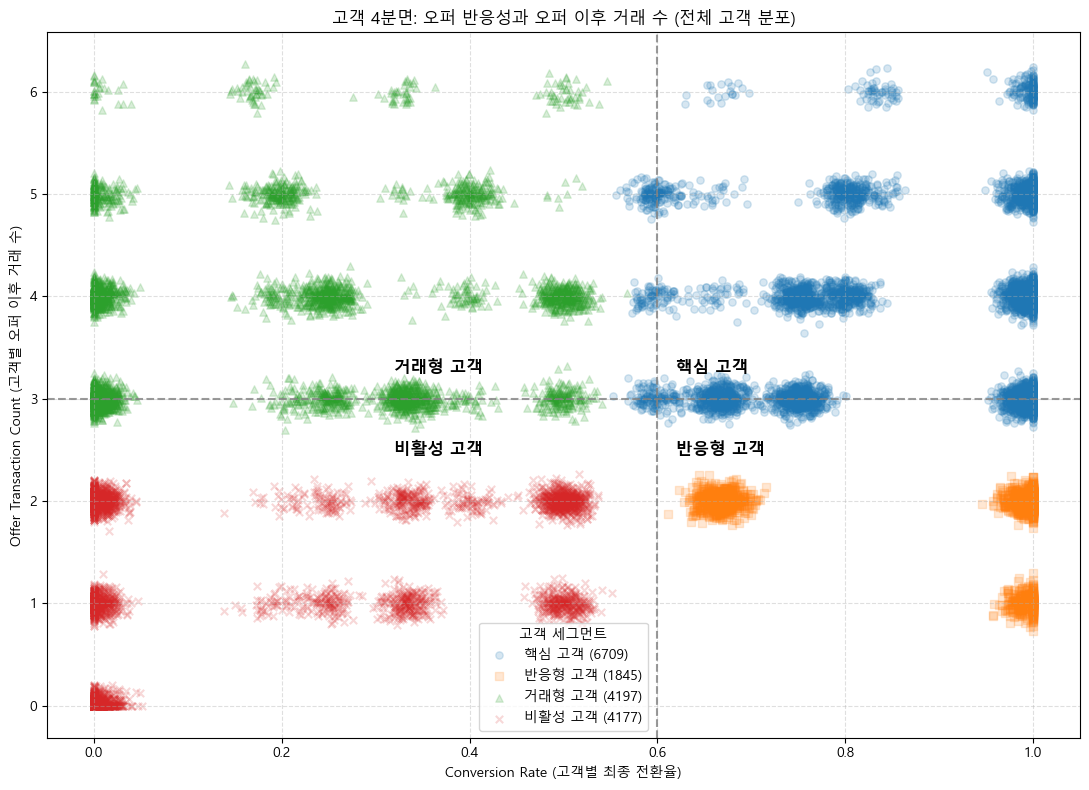


[세그먼트별 평균 요약]


,segment,customer_count,avg_conversion_rate,avg_offer_tx_count
0,핵심 고객,6709,0.891181,3.849158
1,반응형 고객,1845,0.896477,1.821138
2,거래형 고객,4197,0.198416,3.788659
3,비활성 고객,4177,0.173530,1.288963


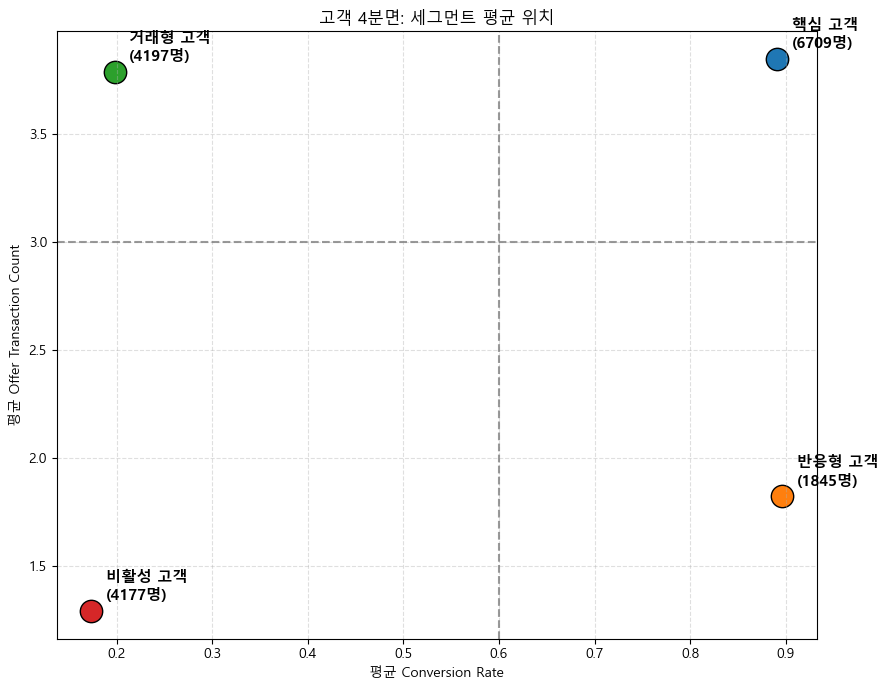

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 고객 단위 지표 생성
# ============================================================
user_conv = rc.groupby("customer_id")["converted_final"].mean()
user_offer_tx_count = rc.groupby("customer_id")["has_transaction"].sum()

user_df = pd.concat([user_conv, user_offer_tx_count], axis=1).reset_index()
user_df.columns = ["customer_id", "conversion_rate", "offer_tx_count"]

# ============================================================
# 2. 4분면 기준선 설정
# ============================================================
x_cut = user_df["conversion_rate"].median()
y_cut = user_df["offer_tx_count"].median()

print(f"conversion_rate 중앙값: {x_cut:.3f}")
print(f"offer_tx_count 중앙값: {y_cut:.3f}")

# ============================================================
# 3. 세그먼트 분류
# ============================================================
def assign_segment(row):
    if row["conversion_rate"] >= x_cut and row["offer_tx_count"] >= y_cut:
        return "핵심 고객"
    elif row["conversion_rate"] >= x_cut and row["offer_tx_count"] < y_cut:
        return "반응형 고객"
    elif row["conversion_rate"] < x_cut and row["offer_tx_count"] >= y_cut:
        return "거래형 고객"
    else:
        return "비활성 고객"

user_df["segment"] = user_df.apply(assign_segment, axis=1)

segment_count = (
    user_df["segment"]
    .value_counts()
    .rename_axis("segment")
    .reset_index(name="customer_count")
)

print("\n[세그먼트별 고객 수]")
display(segment_count)

# ============================================================
# 4. 지터용 좌표 생성
# ============================================================
np.random.seed(42)

user_df["conversion_rate_jitter"] = (
    user_df["conversion_rate"] + np.random.normal(0, 0.015, size=len(user_df))
)
user_df["offer_tx_count_jitter"] = (
    user_df["offer_tx_count"] + np.random.normal(0, 0.08, size=len(user_df))
)

# 너무 튀는 값 방지
user_df["conversion_rate_jitter"] = user_df["conversion_rate_jitter"].clip(0, 1)
user_df["offer_tx_count_jitter"] = user_df["offer_tx_count_jitter"].clip(lower=0)

# ============================================================
# 5. 고객 전체 4분면 산점도 (jitter + alpha)
# ============================================================
segment_order = ["핵심 고객", "반응형 고객", "거래형 고객", "비활성 고객"]
segment_colors = {
    "핵심 고객": "tab:blue",
    "반응형 고객": "tab:orange",
    "거래형 고객": "tab:green",
    "비활성 고객": "tab:red"
}
segment_markers = {
    "핵심 고객": "o",
    "반응형 고객": "s",
    "거래형 고객": "^",
    "비활성 고객": "x"
}

plt.figure(figsize=(11, 8))

for seg in segment_order:
    temp = user_df[user_df["segment"] == seg]
    plt.scatter(
        temp["conversion_rate_jitter"],
        temp["offer_tx_count_jitter"],
        alpha=0.18,
        s=28,
        c=segment_colors[seg],
        marker=segment_markers[seg],
        label=f"{seg} ({len(temp)})"
    )

# 기준선
plt.axvline(x=x_cut, linestyle="--", color="gray", alpha=0.8)
plt.axhline(y=y_cut, linestyle="--", color="gray", alpha=0.8)

# 사분면 라벨
plt.text(x_cut + 0.02, y_cut + 0.25, "핵심 고객", fontsize=12, weight="bold")
plt.text(x_cut + 0.02, max(y_cut - 0.55, 0.15), "반응형 고객", fontsize=12, weight="bold")
plt.text(max(x_cut - 0.28, 0.02), y_cut + 0.25, "거래형 고객", fontsize=12, weight="bold")
plt.text(max(x_cut - 0.28, 0.02), max(y_cut - 0.55, 0.15), "비활성 고객", fontsize=12, weight="bold")

plt.title("고객 4분면: 오퍼 반응성과 오퍼 이후 거래 수 (전체 고객 분포)")
plt.xlabel("Conversion Rate (고객별 최종 전환율)")
plt.ylabel("Offer Transaction Count (고객별 오퍼 이후 거래 수)")
plt.grid(axis="both", linestyle="--", alpha=0.4)
plt.legend(title="고객 세그먼트")
plt.tight_layout()
plt.show()

# ============================================================
# 6. 세그먼트 평균 요약표
# ============================================================
segment_summary = (
    user_df.groupby("segment")
    .agg(
        customer_count=("customer_id", "count"),
        avg_conversion_rate=("conversion_rate", "mean"),
        avg_offer_tx_count=("offer_tx_count", "mean")
    )
    .reset_index()
)

# 보기 좋게 순서 정렬
segment_summary["segment"] = pd.Categorical(
    segment_summary["segment"],
    categories=segment_order,
    ordered=True
)
segment_summary = segment_summary.sort_values("segment").reset_index(drop=True)

print("\n[세그먼트별 평균 요약]")
display(segment_summary)

# ============================================================
# 7. 세그먼트 평균 위치 그래프 (해석용 메인)
# ============================================================
plt.figure(figsize=(9, 7))

for _, row in segment_summary.iterrows():
    seg = row["segment"]
    plt.scatter(
        row["avg_conversion_rate"],
        row["avg_offer_tx_count"],
        s=260,
        c=segment_colors[seg],
        marker="o",
        edgecolors="black",
        linewidths=1.0
    )
    
    plt.text(
        row["avg_conversion_rate"] + 0.015,
        row["avg_offer_tx_count"] + 0.05,
        f"{seg}\n({row['customer_count']}명)",
        fontsize=11,
        weight="bold"
    )

plt.axvline(x=x_cut, linestyle="--", color="gray", alpha=0.8)
plt.axhline(y=y_cut, linestyle="--", color="gray", alpha=0.8)

plt.title("고객 4분면: 세그먼트 평균 위치")
plt.xlabel("평균 Conversion Rate")
plt.ylabel("평균 Offer Transaction Count")
plt.grid(axis="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

**...위 그래프는 기각되었습니다**
x축을 재설정하거나 어떻게 하면될거 같은데 잘 모르겠음

[퍼널 기반 고객 세그먼트]
- 상태	                    의미
not_viewed	            아예 관심 없음
viewed_not_converted	관심은 있음
converted	            행동까지 완료

In [34]:
viewed = df[df["event"] == "offer viewed"][
    ["customer_id", "offer_id", "time"]
].copy().rename(columns={"time": "time_viewed"})

In [35]:
# rc에 viewed 붙이기
rc["has_viewed"] = 0

for (customer_id, offer_id), group in viewed.groupby(["customer_id", "offer_id"]):
    
    viewed_times = group["time_viewed"].values
    
    mask = (rc["customer_id"] == customer_id) & (rc["offer_id"] == offer_id)
    
    for idx in rc[mask].index:
        r_time = rc.loc[idx, "time_received"]
        duration = rc.loc[idx, "duration"] * 24
        
        has_view = np.any(
            (viewed_times >= r_time) &
            (viewed_times <= r_time + duration)
        )
        
        if has_view:
            rc.loc[idx, "has_viewed"] = 1

In [36]:
def make_status(row):
    if row["converted_final"] == 1:
        return "converted"
    elif row["has_viewed"] == 1:
        return "viewed_not_converted"
    else:
        return "not_viewed"

rc["status"] = rc.apply(make_status, axis=1)

In [45]:
import matplotlib.pyplot as plt

def plot_funnel_ratio(df, group_col, title):
    
    pivot = df.groupby([group_col, "status"]).size().unstack().fillna(0)
    ratio = pivot.div(pivot.sum(axis=1), axis=0)

    ax = ratio.plot(
        kind="bar",
        stacked=True,
        figsize=(8,5),
        width=0.6
    )

    # 막대 위에 비율 표시
    for i, (idx, row) in enumerate(ratio.iterrows()):
        bottom = 0
        for j, val in enumerate(row):
            if val > 0.03:  # 너무 작은 값은 표시 안함 (가독성)
                ax.text(
                    i,
                    bottom + val / 2,
                    f"{val*100:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="white",
                    weight="bold"
                )
            bottom += val

    # 스타일 통일
    plt.title(title)
    plt.xlabel(group_col)
    plt.ylabel("비율")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.xticks(rotation=0)

    # 범례 위치 통일 (겹침 방지 핵심)
    plt.legend(
        title="status",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

    return ratio

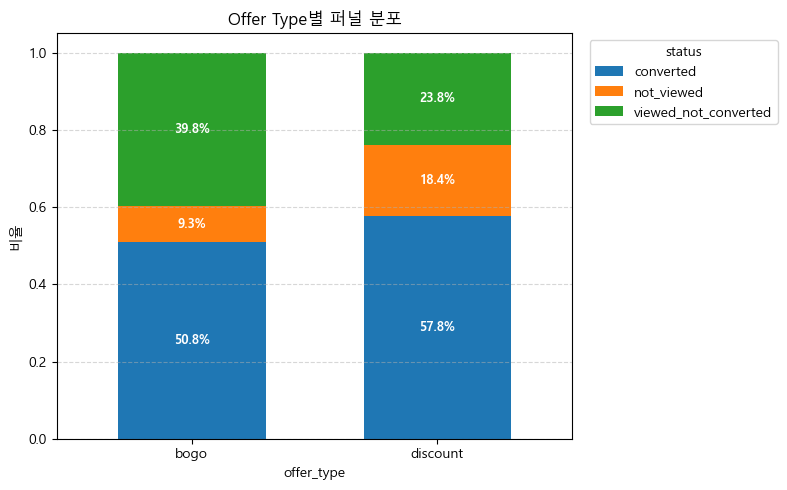

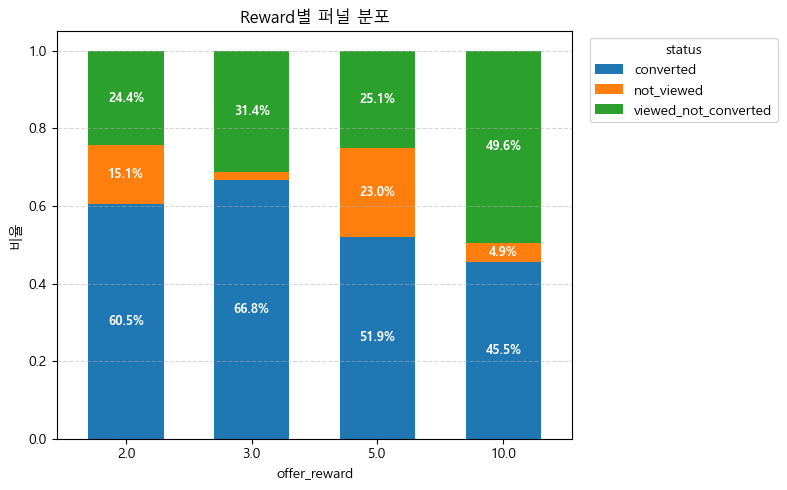

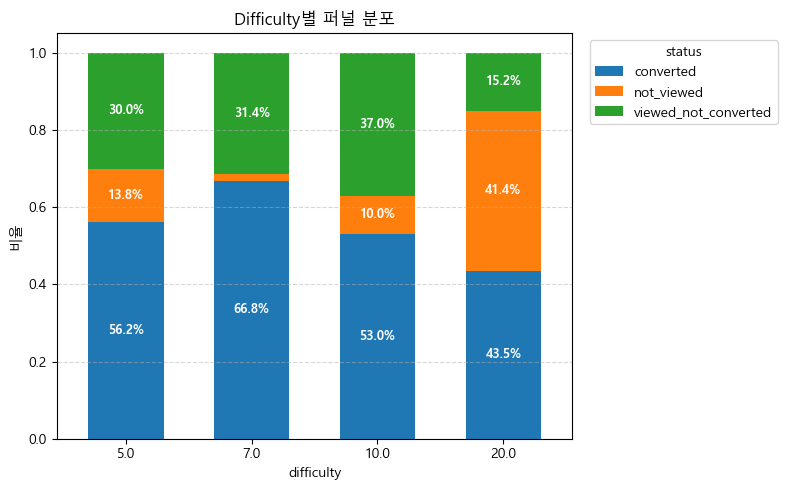

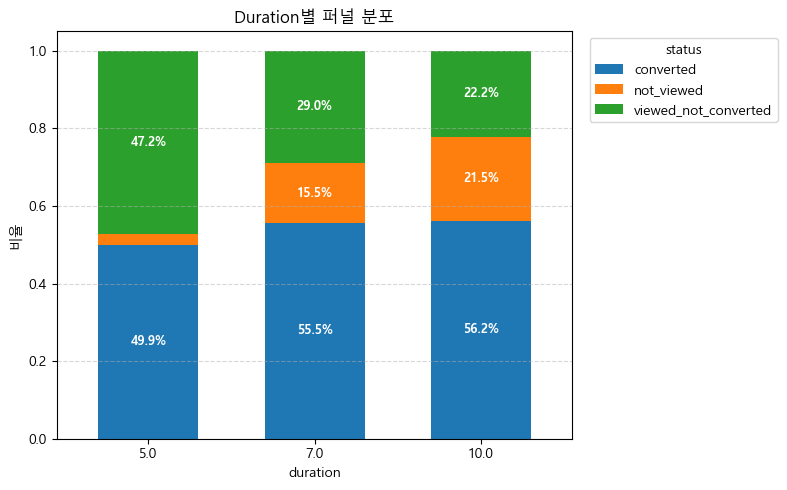

status,converted,not_viewed,viewed_not_converted
duration,,,
5.0,0.498747,0.028884,0.472369
7.0,0.555450,0.155032,0.289518
10.0,0.562398,0.215133,0.222470


In [46]:
plot_funnel_ratio(rc, "offer_type", "Offer Type별 퍼널 분포")
plot_funnel_ratio(rc, "offer_reward", "Reward별 퍼널 분포")
plot_funnel_ratio(rc, "difficulty", "Difficulty별 퍼널 분포")
plot_funnel_ratio(rc, "duration", "Duration별 퍼널 분포")

[offer_type]
- bogo
전환: 50.8%
조회 후 미전환: 39.8%

- discount
전환: 57.8%
조회 후 미전환: 23.8%

bogo는 관심은 유도하지만 실제 전환으로 이어지지 않는 구조
discount는 노출만 되면 높은 전환을 보이는 구조

bogo → 조건 완화 필요 (difficulty ↓)
discount → 노출 확대 (channel 최적화)

[reward]
- reward 3 → 최고 전환 (66.8%)
- reward 10 → 최저 전환 (45.5%) + viewed_not_converted 폭증 (49.6%)

보상이 커질수록 오히려 전환이 감소하고, 조회 후 이탈이 증가
**보상이 커지면: 기대치 ↑ 조건 부담 ↑ => “봐도 포기하는 구조”**

[difficulty]
- difficulty 7 → 최고 전환 (66.8%)
- difficulty 20 → 전환: 43.5% not_viewed: 41.4% (폭증)

**난이도가 높아질수록 아예 보지도 않고 이탈하는 비율 증가**

[duration]
- duration 5 → viewed_not_converted: 47.2% (최대)
- duration 7 → 균형
- duration 10 → 전환 증가

**유효기간이 짧을수록 ‘보고도 못 쓰는’ 이탈 증가**